In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')

print(df.head())

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [3]:
# getting rid of null values and redundant columns
df.drop(columns=['Order_ID', 'Time_of_Day', 'Vehicle_Type'], inplace=True)

print(df.isnull().sum())

for col in ['Weather', 'Traffic_Level', 'Courier_Experience_yrs']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Distance_km                0
Weather                   30
Traffic_Level             30
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
Distance_km               0
Weather                   0
Traffic_Level             0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


Delivery_Speed
Slow      340
Medium    335
Fast      325
Name: count, dtype: int64


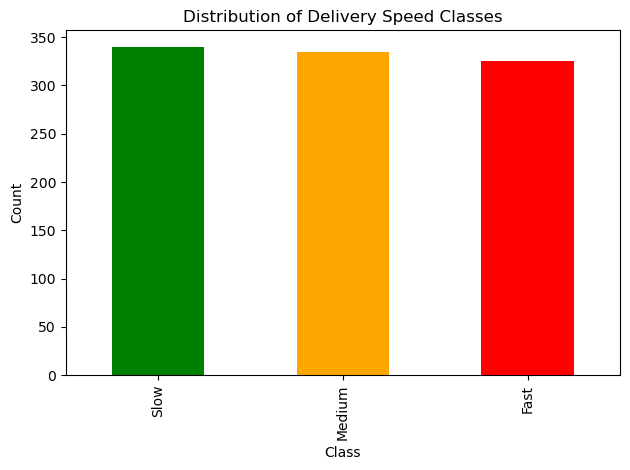

In [4]:
# time delivery range: 6 - 165 minutes
# mean: around 57
# Take around +- 10 from 55, and declarte it as the medium result
def label_speed(t):
    if t < 45:
        return 'Fast'
    elif t <= 65:
        return 'Medium'
    else:
        return 'Slow'

df['Delivery_Speed'] = df['Delivery_Time_min'].apply(label_speed)

print(df['Delivery_Speed'].value_counts())
df['Delivery_Speed'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribution of Delivery Speed Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# one-hot encode categorical values to numerical 
df = pd.get_dummies(df, columns=['Weather', 'Traffic_Level'], drop_first=True, dtype=int)

X = df.drop(columns=['Delivery_Time_min', 'Delivery_Speed'])
y = df['Delivery_Speed']

print('Features:', X.columns.tolist())
print('Target classes:', y.unique())

Features: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium']
Target classes: ['Fast' 'Slow' 'Medium']


In [6]:
#split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=67),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=67)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f'{name}: done')

Logistic Regression: done
KNN: done
Decision Tree: done


In [14]:
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)

# preview of some prediction
preview = pd.DataFrame({'Actual': y_test.values[:10]})
for name, preds in predictions.items():
    preview[name] = preds[:10]
print(X_test.head(10))

print(preview)

     Distance_km  Preparation_Time_min  Courier_Experience_yrs  Weather_Foggy  \
302         9.36                    17                     2.0              0   
305        12.15                    12                     6.0              0   
636         4.39                    12                     8.0              1   
838        12.74                    17                     9.0              0   
359         6.05                    24                     0.0              0   
970         7.97                     9                     8.0              0   
200         1.41                    15                     0.0              1   
521         5.30                    16                     5.0              0   
366         8.25                    24                     4.0              0   
536        10.04                    12                     9.0              0   

     Weather_Rainy  Weather_Snowy  Weather_Windy  Traffic_Level_Low  \
302              1              0    


  Logistic Regression
Accuracy: 0.7550



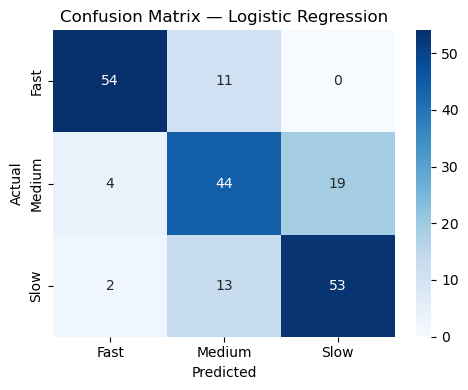

              precision    recall  f1-score   support

        Fast       0.90      0.83      0.86        65
      Medium       0.65      0.66      0.65        67
        Slow       0.74      0.78      0.76        68

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200


  KNN
Accuracy: 0.6850



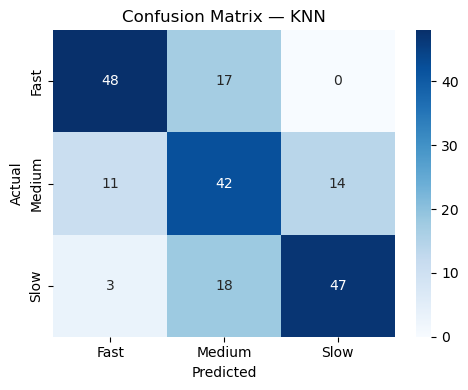

              precision    recall  f1-score   support

        Fast       0.77      0.74      0.76        65
      Medium       0.55      0.63      0.58        67
        Slow       0.77      0.69      0.73        68

    accuracy                           0.69       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.70      0.69      0.69       200


  Decision Tree
Accuracy: 0.7250



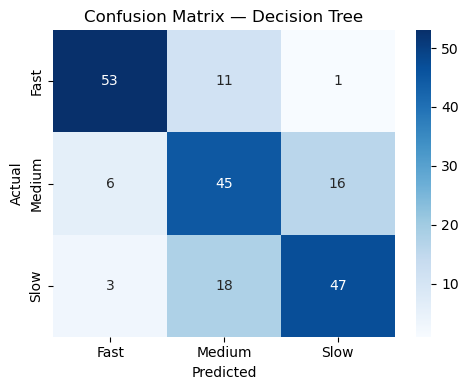

              precision    recall  f1-score   support

        Fast       0.85      0.82      0.83        65
      Medium       0.61      0.67      0.64        67
        Slow       0.73      0.69      0.71        68

    accuracy                           0.72       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.72      0.73       200



In [15]:
class_order = ['Fast', 'Medium', 'Slow']

for name, preds in predictions.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    
    acc = accuracy_score(y_test, preds)
    print(f'Accuracy: {acc:.4f}\n')
    
    cm = confusion_matrix(y_test, preds, labels=class_order)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_order, yticklabels=class_order)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_test, preds, labels=class_order))

Delivery_Speed was created by binning Delivery_Time_min into Fast (<45 min), Medium (45–65 min), and Slow (>65 min) based on the 33rd and 66th percentiles of the data.

Model differences
- Logistic Regression assumes linear decision boundaries. It performed well probably because the data is rather linear
- KNN is sensitive to irrelevant data and large datasets, and because our dataset had quite a few of features that are were barely not irrelevant, KNN performed poorly
- Decision Tree can capture non-linear relationships and performed almost as good as Logistic Regression did

Best Model: Logistic Regression